In [41]:
print(df[["Retweets", "Likes", "Cluster"]].head(10))

   Retweets  Likes  Cluster
0      15.0   30.0        0
1       5.0   10.0        0
2      20.0   40.0        1
3       8.0   15.0        0
4      12.0   25.0        1
5      25.0   50.0        2
6      10.0   20.0        0
7      15.0   30.0        1
8      30.0   60.0        2
9      18.0   35.0        0


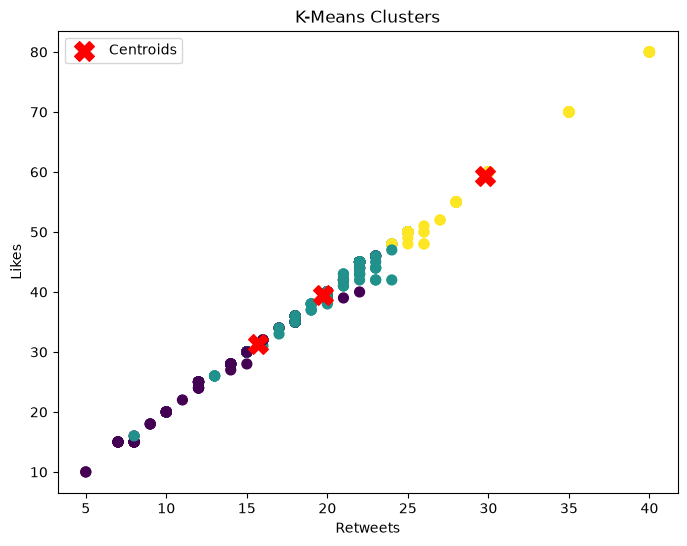

In [40]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df["Retweets"],
            df["Likes"],
            c=df["Cluster"],
            s=50)

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centers[:,0],
            centers[:,1],
            marker='X',
            s=200,
            color='red',
            label='Centroids')

plt.title("K-Means Clusters")
plt.xlabel("Retweets")
plt.ylabel("Likes")
plt.legend()
plt.savefig("kmeans_clusters.png", dpi=300,bbox_inches='tight')
plt.show()

In [35]:
# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[["Retweets", "Likes", "Hour", "Cluster"]].head())

   Retweets  Likes  Hour  Cluster
0      15.0   30.0    12        0
1       5.0   10.0     8        0
2      20.0   40.0    15        1
3       8.0   15.0    18        0
4      12.0   25.0    19        1


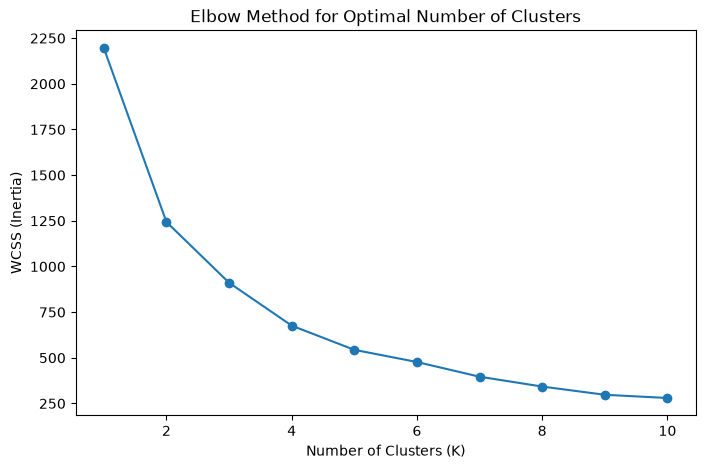

In [34]:
# Calculate Within-Cluster Sum of Squares (WCSS)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.savefig("elbow_plot.png", dpi=300,bbox_inches='tight')
plt.show()

In [31]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Select numerical columns for clustering
X = df[["Retweets", "Likes", "Hour"]]

In [28]:
# Load the dataset
df = pd.read_csv("3) Sentiment dataset.csv")

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler